# ECLAT Cadena Detallista

# Librerías

In [11]:
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx

In [2]:
def build_vertical_db(transactions):
    """Construye la base de datos vertical (TID-list) a partir de las transacciones."""
    vertical_db = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            vertical_db[frozenset([item])].add(tid)
    return dict(vertical_db)


def eclat(prefix, items, min_support, frequent_itemsets, n_transactions):
    """Búsqueda recursiva en profundidad de itemsets frecuentes."""
    while items:
        item, tid_set = items.pop(0)
        new_prefix = prefix | item
        support = len(tid_set)

        if support >= min_support:
            frequent_itemsets[new_prefix] = {
                "support_count": support,
                "support_pct": round(support / n_transactions, 4),
            }
            suffix = []
            for other_item, other_tid_set in items:
                new_tid_set = tid_set & other_tid_set
                if len(new_tid_set) >= min_support:
                    suffix.append((other_item, new_tid_set))
            if suffix:
                eclat(new_prefix, suffix, min_support,
                      frequent_itemsets, n_transactions)


def run_eclat(transactions, min_support=0.3):
    """Ejecuta ECLAT y devuelve los itemsets frecuentes."""
    n = len(transactions)
    min_sup_count = max(1, int(min_support * n))
    vertical_db = build_vertical_db(transactions)

    frequent_1 = {
        item: tids
        for item, tids in vertical_db.items()
        if len(tids) >= min_sup_count
    }

    frequent_itemsets = {
        item: {"support_count": len(tids),
               "support_pct": round(len(tids) / n, 4)}
        for item, tids in frequent_1.items()
    }

    items_list = sorted(frequent_1.items(), key=lambda x: str(sorted(x[0])))
    eclat(frozenset(), items_list, min_sup_count, frequent_itemsets, n)
    return frequent_itemsets


def generate_rules(frequent_itemsets, min_confidence=0.6):
    """Genera reglas de asociación a partir de los itemsets frecuentes."""
    rules = []
    for itemset, stats in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for antecedent in combinations(sorted(itemset), size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                if antecedent in frequent_itemsets:
                    ant_sup = frequent_itemsets[antecedent]["support_count"]
                    confidence = stats["support_count"] / ant_sup
                    if confidence >= min_confidence:
                        con_sup_pct = frequent_itemsets.get(
                            consequent, {}).get("support_pct")
                        lift = round(confidence / con_sup_pct, 4) \
                            if con_sup_pct else None
                        rules.append({
                            "antecedents": set(antecedent),
                            "consequents": set(consequent),
                            "support":     stats["support_pct"],
                            "confidence":  round(confidence, 4),
                            "lift":        lift,
                        })
    return sorted(rules, key=lambda r: r["confidence"], reverse=True)


def results_to_df(frequent_itemsets, rules):
    """Convierte los resultados a DataFrames de pandas."""
    df_items = pd.DataFrame([
        {
            "itemset": ", ".join(sorted(k)),
            "tamaño":  len(k),
            "support_count": v["support_count"],
            "support": v["support_pct"],
        }
        for k, v in frequent_itemsets.items()
    ]).sort_values(["tamaño", "support_count"], ascending=[True, False])

    df_rules = pd.DataFrame([
        {
            "antecedents": frozenset(r["antecedents"]),
            "consequents": frozenset(r["consequents"]),
            "support":     r["support"],
            "confidence":  r["confidence"],
            "lift":        r["lift"],
        }
        for r in rules
    ])

    return df_items, df_rules

## Carga de df

In [3]:
datos = pd.read_csv("../data/data/processed/detallista.csv", delimiter=",")
datos.head()

,Invoice,Reglas
0,489434,"15CM CHRISTMAS GLASS BALL 20 LIGHTS,PINK CHERR..."
1,489435,"CAT BOWL,DOG BOWL , CHASING BALL DESIGN,HEART ..."
2,489436,"DOOR MAT BLACK FLOCK,LOVE BUILDING BLOCK WORD,..."
3,489437,"CHRISTMAS CRAFT HEART DECORATIONS,CHRISTMAS CR..."
4,489438,"DINOSAURS WRITING SET,SET OF MEADOW FLOWER S..."


In [4]:
df_reglas_detallista = datos[["Reglas"]]
df_reglas_detallista.head()

,Reglas
0,"15CM CHRISTMAS GLASS BALL 20 LIGHTS,PINK CHERR..."
1,"CAT BOWL,DOG BOWL , CHASING BALL DESIGN,HEART ..."
2,"DOOR MAT BLACK FLOCK,LOVE BUILDING BLOCK WORD,..."
3,"CHRISTMAS CRAFT HEART DECORATIONS,CHRISTMAS CR..."
4,"DINOSAURS WRITING SET,SET OF MEADOW FLOWER S..."


In [5]:
df_reglas_detallista.shape

(23587, 1)

In [6]:
data_detallista = list(
    df_reglas_detallista["Reglas"].apply(lambda x: [i.strip() for i in str(x).split(",")])
)
data_detallista[:3]

[['15CM CHRISTMAS GLASS BALL 20 LIGHTS',
  'PINK CHERRY LIGHTS',
  'WHITE CHERRY LIGHTS',
  'RECORD FRAME 7" SINGLE SIZE',
  'STRAWBERRY CERAMIC TRINKET BOX',
  'PINK DOUGHNUT TRINKET POT',
  'SAVE THE PLANET MUG',
  'FANCY FONT HOME SWEET HOME DOORMAT'],
 ['CAT BOWL',
  'DOG BOWL',
  'CHASING BALL DESIGN',
  'HEART MEASURING SPOONS LARGE',
  'LUNCHBOX WITH CUTLERY FAIRY CAKES'],
 ['DOOR MAT BLACK FLOCK',
  'LOVE BUILDING BLOCK WORD',
  'HOME BUILDING BLOCK WORD',
  'ASSORTED COLOUR BIRD ORNAMENT',
  'PEACE WOODEN BLOCK LETTERS',
  'CHRISTMAS CRAFT WHITE FAIRY',
  'HEART IVORY TRELLIS LARGE',
  'HEART FILIGREE DOVE LARGE',
  'FULL ENGLISH BREAKFAST PLATE',
  'PIZZA PLATE IN BOX',
  'BLACK DINER WALL CLOCK',
  'SET OF 3 BLACK FLYING DUCKS',
  'AREA PATROLLED METAL SIGN',
  'PLEASE ONE PERSON  METAL SIGN',
  'BATH BUILDING BLOCK WORD',
  'CLASSIC WHITE FRAME',
  'SMALL MARSHMALLOWS PINK BOWL',
  'BISCUITS SMALL BOWL LIGHT BLUE',
  'SCOTTIE DOG HOT WATER BOTTLE']]

In [13]:
# Establezca un valor umbral para el soporte mínimo y ejecute ECLAT
frequent_itemsets_detallista = run_eclat(data_detallista, min_support=0.02)
df_itemsets_detallista, _ = results_to_df(frequent_itemsets_detallista, [])
df_itemsets_detallista

,itemset,tamaño,support_count,support
14,WHITE HANGING HEART T-LIGHT HOLDER,1,3113,0.1320
107,REGENCY CAKESTAND 3 TIER,1,1853,0.0786
0,STRAWBERRY CERAMIC TRINKET BOX,1,1462,0.0620
3,ASSORTED COLOUR BIRD ORNAMENT,1,1340,0.0568
2,HOME BUILDING BLOCK WORD,1,1184,0.0502
...,...,...,...,...
128,"STRAWBERRY CERAMIC TRINKET BOX, SWEETHEART CER...",2,644,0.0273
129,"WOODEN FRAME ANTIQUE WHITE, WOODEN PICTURE FRA...",2,558,0.0237
126,"HOME BUILDING BLOCK WORD, LOVE BUILDING BLOCK ...",2,524,0.0222
125,"HEART OF WICKER LARGE, HEART OF WICKER SMALL",2,492,0.0209


In [14]:
# Reglas de asociación con umbral de confianza mínima
rules_detallista = generate_rules(frequent_itemsets_detallista, min_confidence=0.2)
_, df_ar_detallista = results_to_df(frequent_itemsets_detallista, rules_detallista)
df_ar_detallista

,antecedents,consequents,support,confidence,lift
0,frozenset({SWEETHEART CERAMIC TRINKET BOX}),frozenset({STRAWBERRY CERAMIC TRINKET BOX}),0.0273,0.7559,12.1914
1,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.0309,0.7192,5.4486
2,frozenset({WOODEN PICTURE FRAME WHITE FINISH}),frozenset({WOODEN FRAME ANTIQUE WHITE}),0.0237,0.6723,15.3842
3,frozenset({HEART OF WICKER SMALL}),frozenset({HEART OF WICKER LARGE}),0.0209,0.5572,13.1104
4,frozenset({LOVE BUILDING BLOCK WORD}),frozenset({HOME BUILDING BLOCK WORD}),0.0222,0.5453,10.8619
5,frozenset({WOODEN FRAME ANTIQUE WHITE}),frozenset({WOODEN PICTURE FRAME WHITE FINISH}),0.0237,0.5417,15.3906
6,frozenset({HEART OF WICKER LARGE}),frozenset({HEART OF WICKER SMALL}),0.0209,0.4905,13.1157
7,frozenset({HOME BUILDING BLOCK WORD}),frozenset({LOVE BUILDING BLOCK WORD}),0.0222,0.4426,10.8739
8,frozenset({STRAWBERRY CERAMIC TRINKET BOX}),frozenset({SWEETHEART CERAMIC TRINKET BOX}),0.0273,0.4405,12.2020
9,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETRO SPOT CAKE CASES}),0.0203,0.4194,8.4564


## Visualizaciones

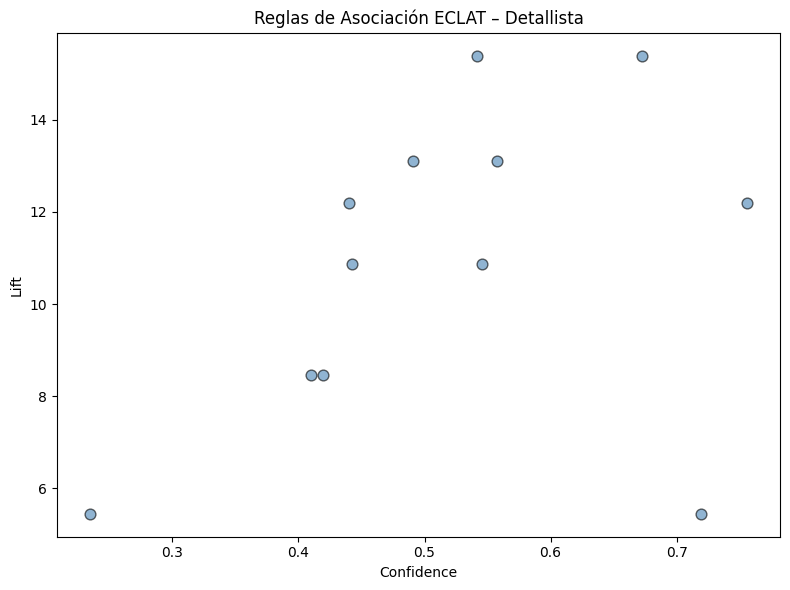

In [16]:
# Scatter plot de confidence vs lift
plt.figure(figsize=(8, 6))
plt.scatter(df_ar_detallista["confidence"], df_ar_detallista["lift"],
            alpha=0.6, c="steelblue", edgecolors="k", s=60)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Reglas de Asociación ECLAT – Detallista")
plt.tight_layout()
plt.show()

# Obtener transacciones

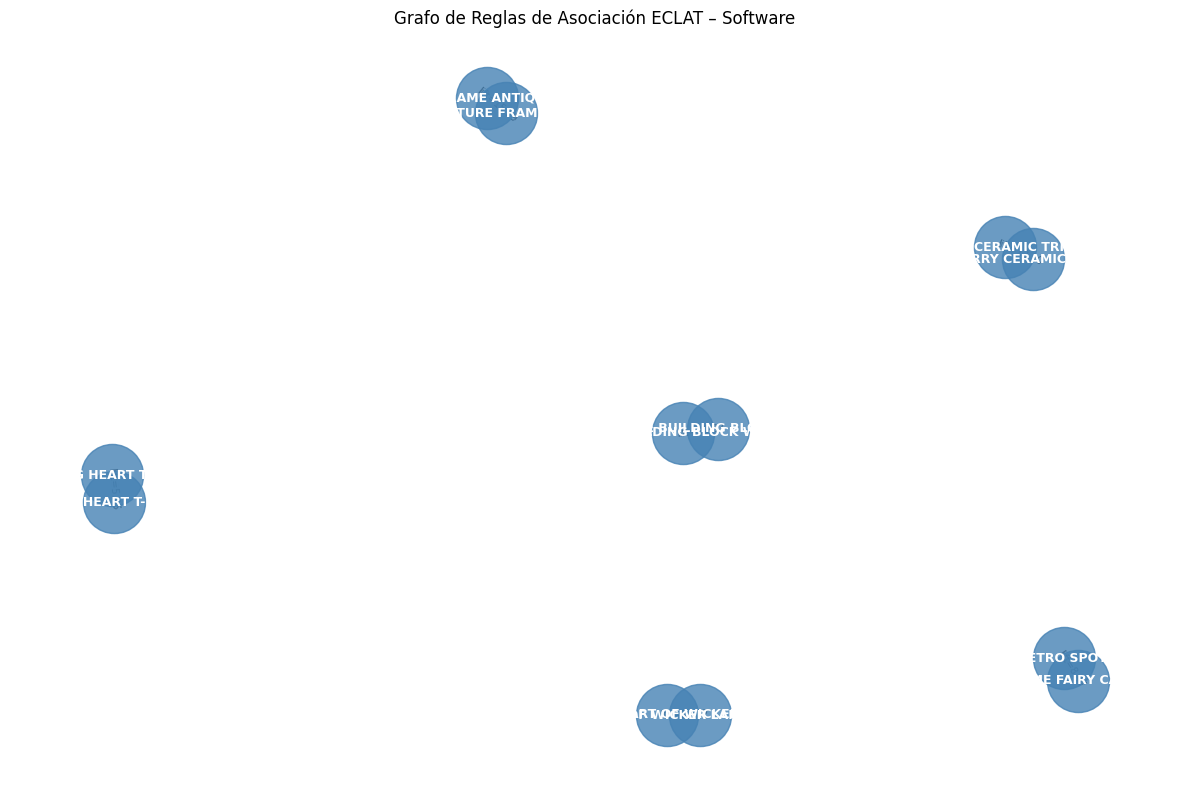

In [17]:
# Visualización de reglas como grafo de red
G = nx.DiGraph()
for _, row in df_ar_detallista.iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    G.add_edge(ant, con, weight=row["lift"])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="steelblue", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                       arrowsize=20, width=1.5)
edge_labels = {(u, v): f"lift={d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Grafo de Reglas de Asociación ECLAT – Software")
plt.axis("off")
plt.tight_layout()
plt.show()